In [1]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

import os
import sys

parent = os.path.abspath("..")
if parent not in sys.path:
    sys.path.append(parent)

from src.config import settings

In [2]:
best_model: YOLO = YOLO(
    model="../models/runs/translation/train1-yolo/weights/best.pt",
    task="detect",
)

best_model.info()

YOLO11n summary: 181 layers, 2,594,910 parameters, 0 gradients, 6.5 GFLOPs


(181, 2594910, 0, 6.4674816)

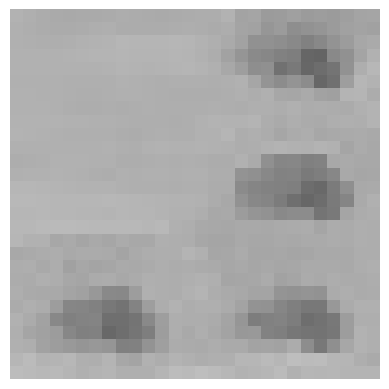

In [3]:
img = cv2.imread("../data/processed/character/301_0_0.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()


0: 32x32 1 a, 2 gs, 1 k, 1 p, 1 r, 1 s, 1 t, 2 us, 1 y, 1 z, 6.1ms
Speed: 1.9ms preprocess, 6.1ms inference, 157.7ms postprocess per image at shape (1, 3, 32, 32)
Box: tensor([ 0.6299,  0.0000, 28.0000, 26.2834], device='cuda:0')
Confidence: 0.42910367250442505
Class: 17


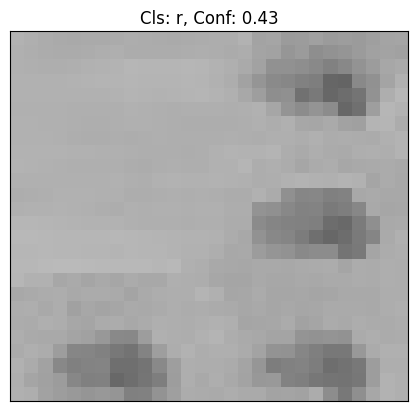

In [4]:
predictions = best_model.predict(img, conf=0.0)
prediction = predictions[0]

index = prediction.boxes.conf.argmax()
box = prediction.boxes.xyxy[index]
conf = prediction.boxes.conf[index]
cls = prediction.boxes.cls[index].int()
character = settings.CHARACTERS_LOWERCASE[cls]

print(f"Box: {box}")
print(f"Confidence: {conf}")
print(f"Class: {cls}")

box_int = box.int().cpu().tolist()
img_predicted = img[box_int[1]:box_int[3], box_int[0]:box_int[2]]
plt.title(f"Cls: {character}, Conf: {conf:.2f}")
plt.imshow(img_predicted)
plt.xticks([]), plt.yticks([])
plt.show()


In [5]:
display(
    prediction.boxes.xyxy.int().tolist(),
    prediction.boxes.cls.int().tolist(),
    prediction.boxes.conf.tolist(),
)

[[0, 0, 28, 26],
 [0, 0, 28, 26],
 [0, 0, 27, 25],
 [1, 0, 28, 25],
 [0, 0, 27, 26],
 [17, 0, 27, 26],
 [0, 1, 14, 26],
 [0, 0, 11, 25],
 [0, 0, 11, 24],
 [0, 0, 11, 24],
 [8, 0, 28, 27],
 [0, 0, 28, 28]]

[17, 19, 25, 18, 20, 24, 15, 20, 0, 10, 6, 6]

[0.42910367250442505,
 0.19110587239265442,
 0.18080933392047882,
 0.1302800178527832,
 0.02273801900446415,
 0.010424475185573101,
 0.0062102265655994415,
 0.004049098119139671,
 0.003441798035055399,
 0.0005388323916122317,
 0.0004296446277294308,
 4.20080941694323e-05]